# APSIDE: Hydrostatic Component
## Written by: Liam Colombo-Murphy and M. Grant Roberts

You will only need to edit the variables in the last cell which are: "data_file" and "PCentral". The data_file is the path to your data and PCentral is the range of central pressures which you run the solver over. Please read the relevant comment above these variables for more information. The file format of your data should be "pressure, energy_density" - one row at a time. The code will automatically create an output file called "data_0" which contains the history of the rk4 solver. The code will also automatically create a mass versus radius plot for your given data_file. If you have multiple data files to run, you can simply just create a loop over a list of data file names and the code will output its results into files in the format "data_#" where # = the current data file, with the first data file starting at index of 0. 

In [2]:
# Imports
import matplotlib.pyplot as plt
import numpy as np
import os
from scipy.interpolate import interp1d
from scipy.integrate import odeint
from scipy.integrate import solve_ivp
from NaturalConstants import *

In [3]:
# Constants
tiny = 1e-20
G = 6.67408e-8       # dyne cm^2 / g^2
c = 2.99792458e+10   # cm/s   #SoL 

def func(x, y, rho_interp):
    '''
    Gives TOV Equations to be solved by rk4 function
        k[0] = dm/dr
        k[1] = dP/dr
    '''
    k = np.zeros(len(y))
    
    # y[0] = mass(r)
    # y[1] = pressure(r)

    mass = y[0] + tiny
    pressure = y[1]
    rho = rho_interp(pressure)
    radius = x + tiny

    if rho <= 0 or np.isnan(rho):
        return np.zeros(len(y))  # Stop integration safely
    
    
    k[0] = 4*np.pi*rho*radius**2              # dm/dr
    k[1] = -1*G*mass*rho/radius**2            # dP/dr
    
    return k


def rk4(a, b, alpha, N, data_label, rho_interp, pressure_cutoff = 1e-20):
    '''
    Runge-Kutta 4th Order Method
        t = scanning variable
        a, b such that a <= t <= b, a is radius of object's center, b should be greater than the star's surface radius
        alpha = inital condition y(a) = alpha, [m(r=0), P(r=0)]
        N = number of iterations
        rho_interp = rho(P), energy density as function of Pressure
    '''

    k1, k2, k3, k4, func_val = [], [], [], [], []
    
    t = a
    w = alpha
    h = (b - a) / N
    
    with open('data_'+str(data_label)+'.txt','w') as file:
        file.writelines([str(t),', ', str(w[0]),', ',str(w[1]),', ', str(h),'\n'])

    mass_lim = [w[0],]
    
    i = 1
    while( i < N ):
        k1 = h * func(t, w, rho_interp)
        k2 = h * func(t + h/2, w + k1/2, rho_interp)
        k3 = h * func(t + h/2, w + k2/2, rho_interp)
        k4 = h * func(t + h,   w + k3, rho_interp)

        t = a + i*h 
        w = w + (k1 + 2*k2 + 2*k3 + k4)/6.0
        x_val = t     # return the x_value              This gives the i'th radius
        func_val = w  # return the function_value       This gives your i'th mass then pressure in array, [m_i, P_i]

        mass_lim.append(func_val[0])
    
        if (func_val[1] > pressure_cutoff) and (func_val[0] > mass_lim[i-1]):
            with open('data_'+str(data_label)+'.txt','a') as file:
                file.writelines([str(x_val),', ', str(func_val[0]),', ',str(func_val[1]),', ', str(h),'\n']) #radius, mass, pressure, delta/step width   
        
        else:                    
            break
            
        i+=1


def eta_equation(r, eta, R_dep): 
    '''
    Inputs:
        r - radius in cm where current part of solution is being solved for
        y - differential parameter
        R_dep: 
            e_R - energy density profile as function of radius, 1/cm^2 
            P_R - pressure profile as function of radius, 1/cm^2
            m_R - enclosed mass at radius r, cm
    Outputs:
        dydr - differential in y and r, to be solved by solve_y
    
    ''' 
    rho_interp, P_interp, m_interp, surface_radius = R_dep

    R = surface_radius
    P = P_interp(r)
    rho = rho_interp(r)
    m = m_interp(r)

    rho_bar = 3*m/(4*np.pi*r**3)

    detadr = -1/r*( eta**2 - eta - 6 + 6*rho/rho_bar*(1+eta) )

    return detadr

def solve_eta(R_dep):
    '''
    Takes differential of y (dy/dr) defined in previous function and integrates it from the core to the surface of the object
    Then selects the value of yR = y(R) with R being R_surface. 
    '''
    rho_interp, P_interp, m_interp, surface_radius = R_dep

    R = surface_radius # cm
    sol_eta = solve_ivp(eta_equation, t_span = [1, R], y0 = [0.0], args = [R_dep], method = 'RK45',) # args=(P_interp, rho_interp, m_interp),
    etaR = sol_eta.y[0,-1]

    return etaR

def solve_tidal(R_dep):
    '''
    Constants:
        R - surface radius in cm
        M - total mass of body in cm
        y - dimensionless parameter y solved in differential
    Outputs:
        R/1e5 - radius of body in km
        M/(Msun * 1e3) - mass of body in Msun
        C - compactness of body
        k2 - tidal love number k2
        y, beta, H - values used to calculate k2
    '''
    rho_interp, P_interp, m_interp, surface_radius = R_dep
    
    R = surface_radius       # in cm
    M = m_interp(R)          # in cm

    eta = solve_eta([rho_interp, P_interp, m_interp, R])
    
    k2 = 1/2 * (3-eta)/(2+eta)

    return np.array([R/1e5 , M/1.898e30, k2, eta])#, beta, H])

In [12]:
# to start the solver, i need the central pressure and central energy density. to then create the next point i need
# the energy density as a function of pressure. i make the assumption that the data that is being read in from
# the data file is something of the form: pressure, energy_density(pressure) for each row. ie, the first column will
# have the pressure values, and the next column within the same row will have the energy_density as a function of that
# pressure value. the code does not need any pressure value aside from the central pressure, but the energy density 
# does. so what we do is we create an interpolation object in energy density and use that as our energy_density function
# for the code to use.


def plotter(txt = 'FileNamewithout_txt'):
    data = np.loadtxt( txt + '.txt')
    xdata = data[:, 0]
    ydata = data[:, 1]

    return xdata, ydata


def read_data(infile):
    '''
    Calls EOS file, the file must take the form: 
    Pressure [MeV/fm^3], Energy Density [MeV/fm^3] for the solver to work properly
    '''
    
    with open(infile,'r') as in_file:
        file = in_file.readlines()
        pressure_list = np.zeros(len(file))
        density_list = np.zeros(len(file))
        
        for j in range(len(file)):
            pressure = float(file[j].split(',')[0])
            density = float(file[j].split(',')[1].rstrip('\n'))
            
            pressure_list[j] = pressure
            density_list[j] = density

        # Pa, kg/m^3
        # pressure_list = pressure_list/10              # Pa ---> dyn/cm^2 (1 Pa = 10 dyn/cm^2)
        # density_list = density_list/1000              # kg/m^3 ---> g/cm^3 (1 g/cm^3 = 1000 kg/m^3)

        # Mbar, g/cm^3
        pressure_list = pressure_list*1e12              # Mbar ---> dyn/cm^2 (1 Mbar = 1e12 dyn/cm^2)
        density_list = density_list                     #g/cm^3
        
       
    plt.plot(density_list, pressure_list, color = 'slateblue')

    
    plt.title('Equation of State for ' + str(infile))
    plt.xlabel(r'$\rho ~ (g/cm^3)$')
    plt.ylabel(r'P $(dyne/cm^2)$')
    plt.xscale('log')
    plt.yscale('log')
    plt.tight_layout()
    plt.show()

    return pressure_list, density_list
  

def main(PCentral, density_interp_function, step_end = 80000, stepcount = 1e3):
    a = 1e-10               #Starting radius of rk4, small but not zero to avoid possible division by zero, 1e-20
    b = step_end * 1e5      #This is the endpoint of the rk4 solver scanning range in cm, multiplying by 10^5 gives cm, 50000e5
    final_mass = []
    final_radius = []
    final_pressure = []

    final_k2 = []
    final_lambda = []
    final_compactness = []
    
    for i in range(len(PCentral)):
        alpha = [0.0, PCentral[i]] #[m(r=0), P(r=0)]

        rk4(a, b, alpha, stepcount, i, density_interp_function)    #1000
        #print('-------------------------------------')
        mass_array = []
        radius_array = []
        pressure_array = []
        density_array = []
        
        with open('data_'+str(i)+'.txt') as file:
            in_file = file.readlines()
            for j in range(len(in_file)):
                mass = float(in_file[j].split(',')[1].split()[0])
                pressure = float(in_file[j].split(',')[2].split()[0])
                radius = float(in_file[j].split(',')[0])
                density = float(density_interp(pressure)) #Usual
                
                mass_array.append(mass) # g
                radius_array.append(radius) # cm
                pressure_array.append(pressure) # dyne/cm^2
                density_array.append(density)   #g/cm^3


            mass_holder = mass_array[-1]
            radius_holder = radius_array[-1]
            pressure_holder = pressure_array[-1]

            
            final_mass.append(mass_holder)
            final_radius.append(radius_holder)
            final_pressure.append(pressure_holder)

            if len(radius_array) < 4:
                print(f"Not enough points to interpolate for model {i}")
                continue

            rho_R = interp1d(radius_array, density_array, kind='cubic')                      #cubic
            P_R = interp1d(radius_array, pressure_array, kind='cubic', bounds_error=True)    #cubic
            m_R = interp1d(radius_array, mass_array, kind='linear', bounds_error=True)       #cubic


            
            Radius_body, Mass_Mjup, k2, eta = solve_tidal([rho_R, P_R, m_R, radius_holder])

            tidal_lambda = 2*radius_holder**5/(3*6.6743e-8) * k2
            
            final_k2.append(k2)
            final_lambda.append(tidal_lambda)
    
            plt.plot(np.array(radius_array)/1e5, np.array(mass_array)/1.898e30)

        if not np.all(np.diff(radius_array) > 0):
            print("Warning: radius array is not strictly increasing!")
    

    plt.title('Each mass-radius curve for a specific central density')
    plt.xlabel(r'R (km)')
    plt.ylabel(r'$M~(M_{J})$')
    # plt.xscale('log')
    # plt.yscale('log')
    plt.tight_layout()

    plt.show()

    if (len(PCentral) > 1):

        # 2x2 Plot of Mass-Radius, Mass-k2, and Mass-Tidal Deformabilities
        fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(9, 7),)
        
        # Plot on the first subplot (top-left)
        axes[0, 0].plot(np.array(final_mass)/1.898e30, np.array(final_radius)/1e5, '-', color = 'darkturquoise')
        
        axes[0, 0].set_ylabel(r'R (km)')
        axes[0, 0].set_xlabel(r'M $(M_{J})$')
        axes[0, 0].set_xscale('log')
        axes[0, 0].set_yscale('log')
        
        
        # Plot on the second subplot (top-right)
        axes[0, 1].plot(np.array(final_mass)/1.898e30, final_k2, linestyle = '-', color = 'darkturquoise')
        
        axes[0, 1].set_ylabel(r'$k_{2}$')
        axes[0, 1].set_xlabel(r'$M~(M_{J})$')
        axes[0, 1].set_xscale('log')

        
        # Plot on the third subplot (bottom-left)
        axes[1, 0].plot(np.array(final_mass)/1.898e30, np.array(final_lambda)*c**10/(G**4 * np.array(final_mass)**5), '-', color = 'darkturquoise')

        axes[1, 0].set_ylabel(r'$\Lambda$')
        axes[1, 0].set_xlabel(r'M $(M_{J})$')
        axes[1, 0].set_yscale('log')
        axes[1, 0].set_xscale('log')

        
        # Plot on the fourth subplot (bottom-right)
        axes[1, 1].plot(np.array(final_mass)/1.898e30, np.array(final_lambda), '-', color = 'darkturquoise')
 
        axes[1, 1].set_ylabel(r'$\lambda~(\text{g} \text{cm}^2 \text{s}^2)$')
        axes[1, 1].set_xlabel(r'$M~(M_{J})$')
        axes[1, 1].set_yscale('log')
        axes[1, 1].set_xscale('log')

        plt.tight_layout()
        plt.show()

        # Save Arrays for plotting in other notebooks
        EOSname = 'Fe'
        # np.savetxt(str(EOSname) + '_masses.txt', np.array(final_mass), delimiter=" ")
        # np.savetxt(str(EOSname) + '_radii.txt', np.array(final_radius), delimiter=" ")
        # np.savetxt(str(EOSname) + '_k2s.txt', np.array(final_k2), delimiter=" ")
        # np.savetxt(str(EOSname) + '_lambdas.txt', np.array(final_lambda), delimiter=" ")

# List of Some Equations of State:

#### EOS Name $\in$ [A Good PCentral range]:



##### Rocky Planets:
*It can be helful to increase step count to push to lower central pressures* \
Fe_EOS-(Mbar_gcm^3)        $~~~\in~ $[5e9, 1e17]   \
H2O_EOS-(Mbar_gcm^3)       $~~~\in~ $[1e9, 1e17]   \
MgSiO3_EOS-(Mbar_gcm^3)    $~~~\in~ $[2.4e10, 1e17]                                             

##### Carbonaceous EOS:
SiC_EOS-(Mbar_gcm^3)       $~~~\in~ $[1.67e10, 1e17] \
DiamondEOS-(Mbar_gcm^3)    $~~~\in~ $[1e12, 1e14]  \
CO_EOS-(Mbar_gcm^3)        $~~~\in~ $[2e9, 4e15]  \
Cold_C_EOS-(Mbar-gcm^3)    $~~~\in~ $[1e8, 1e25]  \
Cold_CO_EOS-(Mbar-gcm^3)   $~~~\in~ $[1e8, 1e25]

##### Hydrogen/Helium:
H_EOS_0Temp-(Mbar-gcm^3)   $~~~\in~ $[1e4, 1e18]  \
He_EOS_0Temp-(Mbar-gcm^3)   $~~~\in~ $[1e4, 1e19]  \
H-He_EOS_0Temp-(Mbar-gcm^3)  $~~~\in~ $[1e4, 1e19]


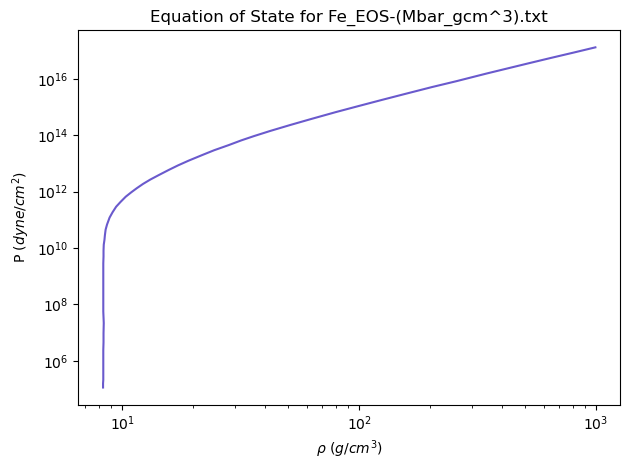

C:\Users\liamv\AppData\Local\Temp\ipykernel_50072\4106953426.py:27: RuntimeWarning: overflow encountered in multiply
  k[1] = -1*G*mass*rho/radius**2            # dP/dr


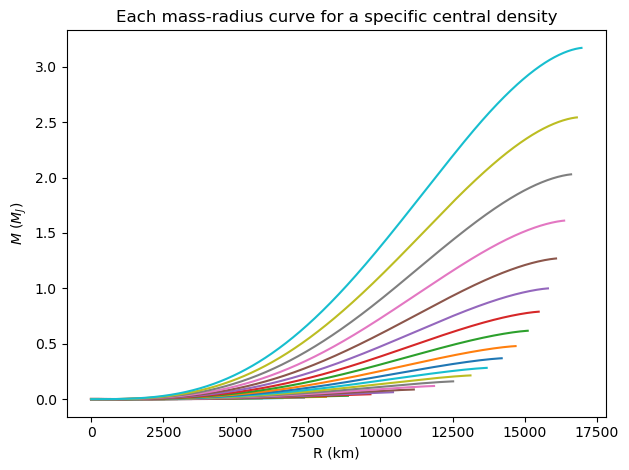

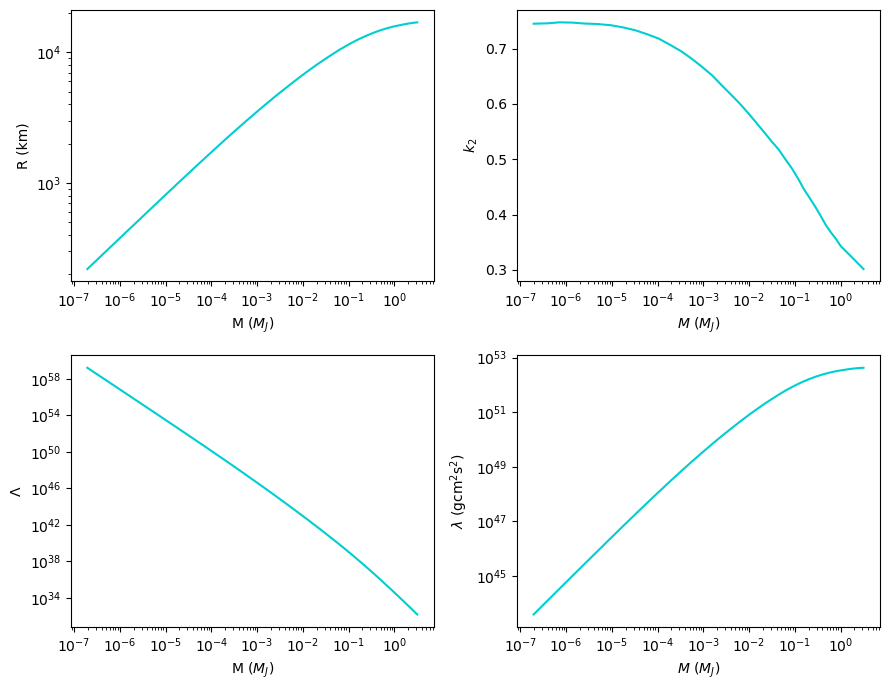

In [15]:
# This is the only piece of the code you need to edit. 
# data_file = the path to the file that has your pressure/energy_density values
# PCentral = range of central pressures solver runs over
# ---------------------------------------------------------------------
data_file = 'Fe_EOS-(Mbar_gcm^3).txt'
PCentral = np.geomspace(5e9, 1e17, 40)
# ---------------------------------------------------------------------

pressure_data, density_data = read_data(data_file)
density_interp = interp1d(pressure_data, density_data, bounds_error=False, fill_value="extrapolate", kind='cubic') #gives rho(P) in CGS

main(PCentral, density_interp, 2e4, 1e3)  # Range of Central Pressures, Density interpolation function, Max Radius, Step Count (increase for precision at cost of runtime)